# Cross-cell-line Factor Comparison


In [1]:
import pickle

from cc_tensor import cross_cellline_protein_factors, cross_cellline_treatment_factors, cross_cellline_protein_factors_by_treatment
from cc_tensor_viz import cross_cellline_embedding, cross_cellline_clustermap


/Users/kaiwycik/.pyenv/versions/3.13.3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load results:


In [2]:
CELL_LINES = ["134", "231", "44PE", "453", "BCK4", "MCF10A", "MCF7", "T47D"]

cct_dict = {}
for name in CELL_LINES:
    with open(f"results/cct_{name}.pkl", "rb") as f:
        cct_dict[name] = pickle.load(f)


In [3]:
protein_factor_df = cross_cellline_protein_factors(cct_dict)
treatment_factor_df = cross_cellline_treatment_factors(cct_dict)

print(f"Protein factor matrix: {protein_factor_df.shape}")
print(f"Treatment factor matrix: {treatment_factor_df.shape}")
protein_factor_df.head(8)

Protein factor matrix: (32, 22)
Treatment factor matrix: (64, 22)


Ki67  nuclear_area       p16      CDH1     cycA2  \
cell_line factor                                                           
134       Factor 1  0.309054      0.260058  0.154763  0.187813  0.313548   
          Factor 2 -0.110047     -0.082420  0.269523  0.044868 -0.071779   
          Factor 3  0.064151     -0.107542 -0.031495 -0.291430 -0.075623   
          Factor 4  0.025851      0.178994  0.173912  0.124937  0.041741   
231       Factor 1  0.166754      0.213476  0.242238  0.101870  0.283000   
          Factor 2 -0.358488     -0.010658  0.087476  0.055417 -0.158718   
          Factor 3  0.077960     -0.345857 -0.122165  0.498515 -0.109670   
          Factor 4  0.088327     -0.143011 -0.331186  0.079764  0.070779   

                       cycE1      CDK2        RB     CycB1       p21  ...  \
cell_line factor                                                      ...   
134       Factor 1  0.011401  0.294478  0.263454  0.289473  0.124638  ...   
          Factor 2  0.360109  0.086330  0.163305 -0.073377  0.075582  ...   
          Factor 3  0.172004  0.145614  0.147249 -0.252133 -0.504886  ...   
          Factor 4  0.114970  0.001032  0.166131  0.058611 -0.130292  ...   
231       Factor 1  0.200141  0.283057  0.283315  0.159846  0.219409  ...   
          Factor 2  0.307953 -0.010055 -0.039887 -0.299900  0.068270  ...   
          Factor 3 -0.044338 -0.214487 -0.172178  0.163036  0.212789  ...   
          Factor 4  0.234935  0.043985 -0.074072 -0.212884 -0.243337  ...   

                        CDK4     cycA1      PCNA       p53       p27  \
cell_line factor                                                       
134       Factor 1  0.047704  0.168426  0.244166  0.152372 -0.081468   
          Factor 2  0.344536  0.181334 -0.049968  0.030895  0.366391   
          Factor 3  0.102507  0.021735  0.365364  0.224173 -0.105640   
          Factor 4  0.300213 -0.447069 -0.115355 -0.644374 -0.071841   
231       Factor 1  0.255212  0.191378  0.251170  0.225159  0.170364   
          Factor 2  0.232973  0.177790 -0.116429 -0.066915  0.256869   
          Factor 3 -0.142637  0.323891 -0.157177 -0.053072  0.328011   
          Factor 4  0.100340  0.072552  0.282800 -0.399779 -0.027228   

                       cycB2      SKP2      CDT1     cycE2   DNA_int  
cell_line factor                                                      
134       Factor 1  0.296771  0.301653 -0.128023  0.105636  0.279074  
          Factor 2 -0.067926  0.021984  0.244659  0.341412 -0.076531  
          Factor 3 -0.231503  0.170020 -0.297924  0.217011 -0.198424  
          Factor 4  0.027035  0.188062 -0.166458  0.023581 -0.190074  
231       Factor 1  0.188823  0.266094 -0.035232  0.217141  0.170020  
          Factor 2 -0.271870 -0.158580  0.292482  0.183208 -0.309509  
          Factor 3  0.286405 -0.151781 -0.018180  0.159940  0.239003  
          Factor 4 -0.088109  0.148076 -0.442720  0.372898 -0.109075  

[8 rows x 22 columns]

### 7.1 Protein factor embeddings:

We stack the protein loading vectors $P_{:,f}$ from all cell lines into a single matrix of shape $(p_F \times L) \times p$, where $L = 8$ is the number of cell lines and $p_F$ the number of protein factors. Each row is a 22-dimensional protein-space vector representing one factor from one cell line. PCA and UMAP projections show whether analogous factors (e.g., Factor 1 across all cell lines) cluster together, which would indicate a shared protein program. The cosine-similarity clustermap quantifies pairwise alignment of these loading vectors.

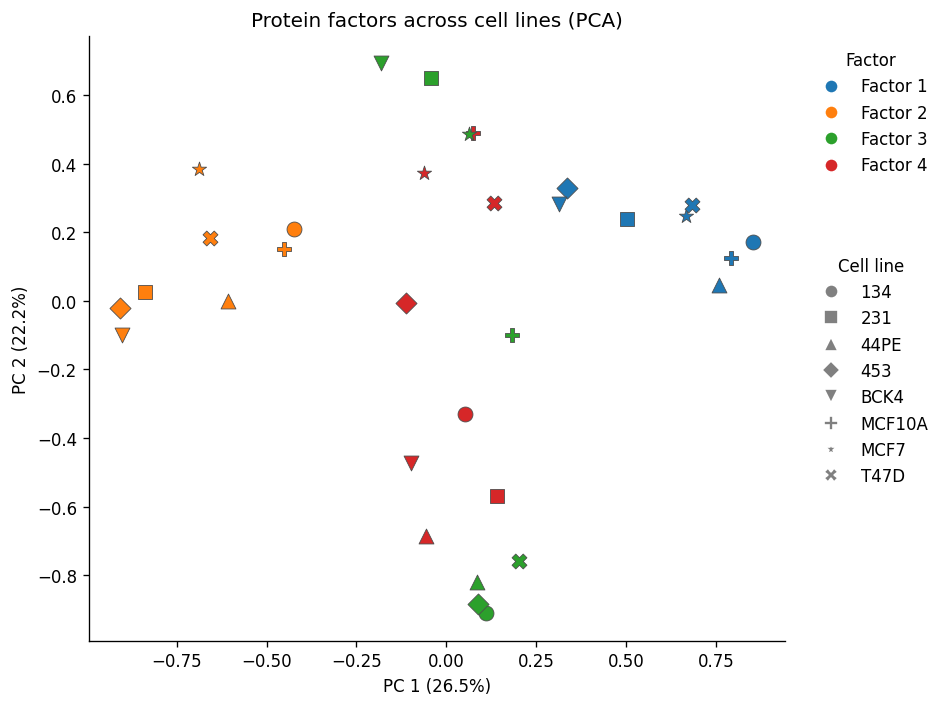

In [4]:
cross_cellline_embedding(
    protein_factor_df, method="pca",
    title="Protein factors across cell lines (PCA)"
);

/Users/kaiwycik/.pyenv/versions/3.13.3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


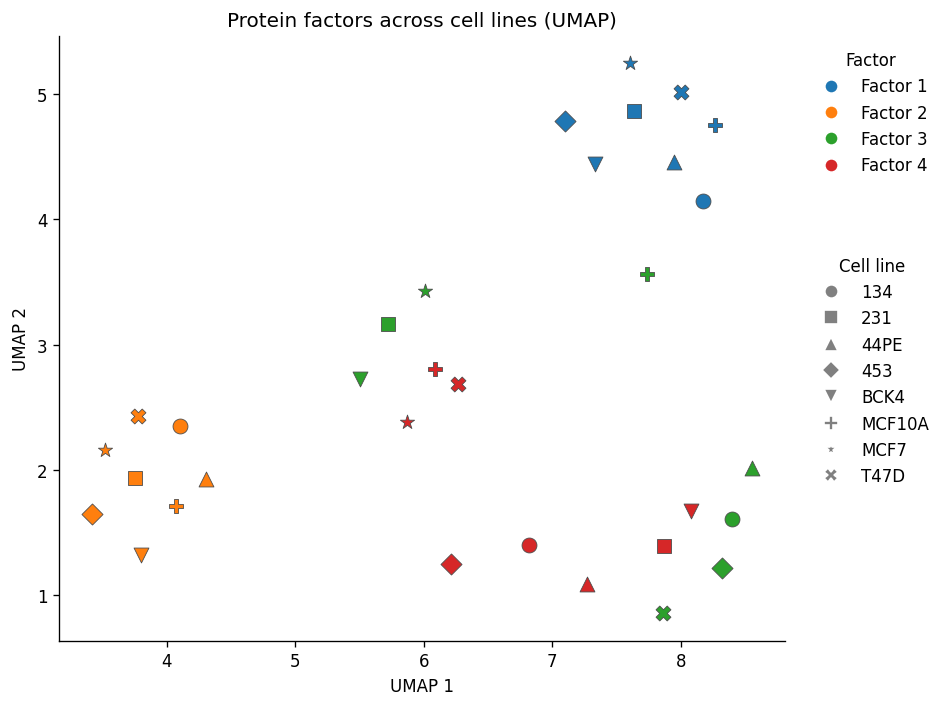

In [5]:
cross_cellline_embedding(
    protein_factor_df, method="umap",
    title="Protein factors across cell lines (UMAP)"
);

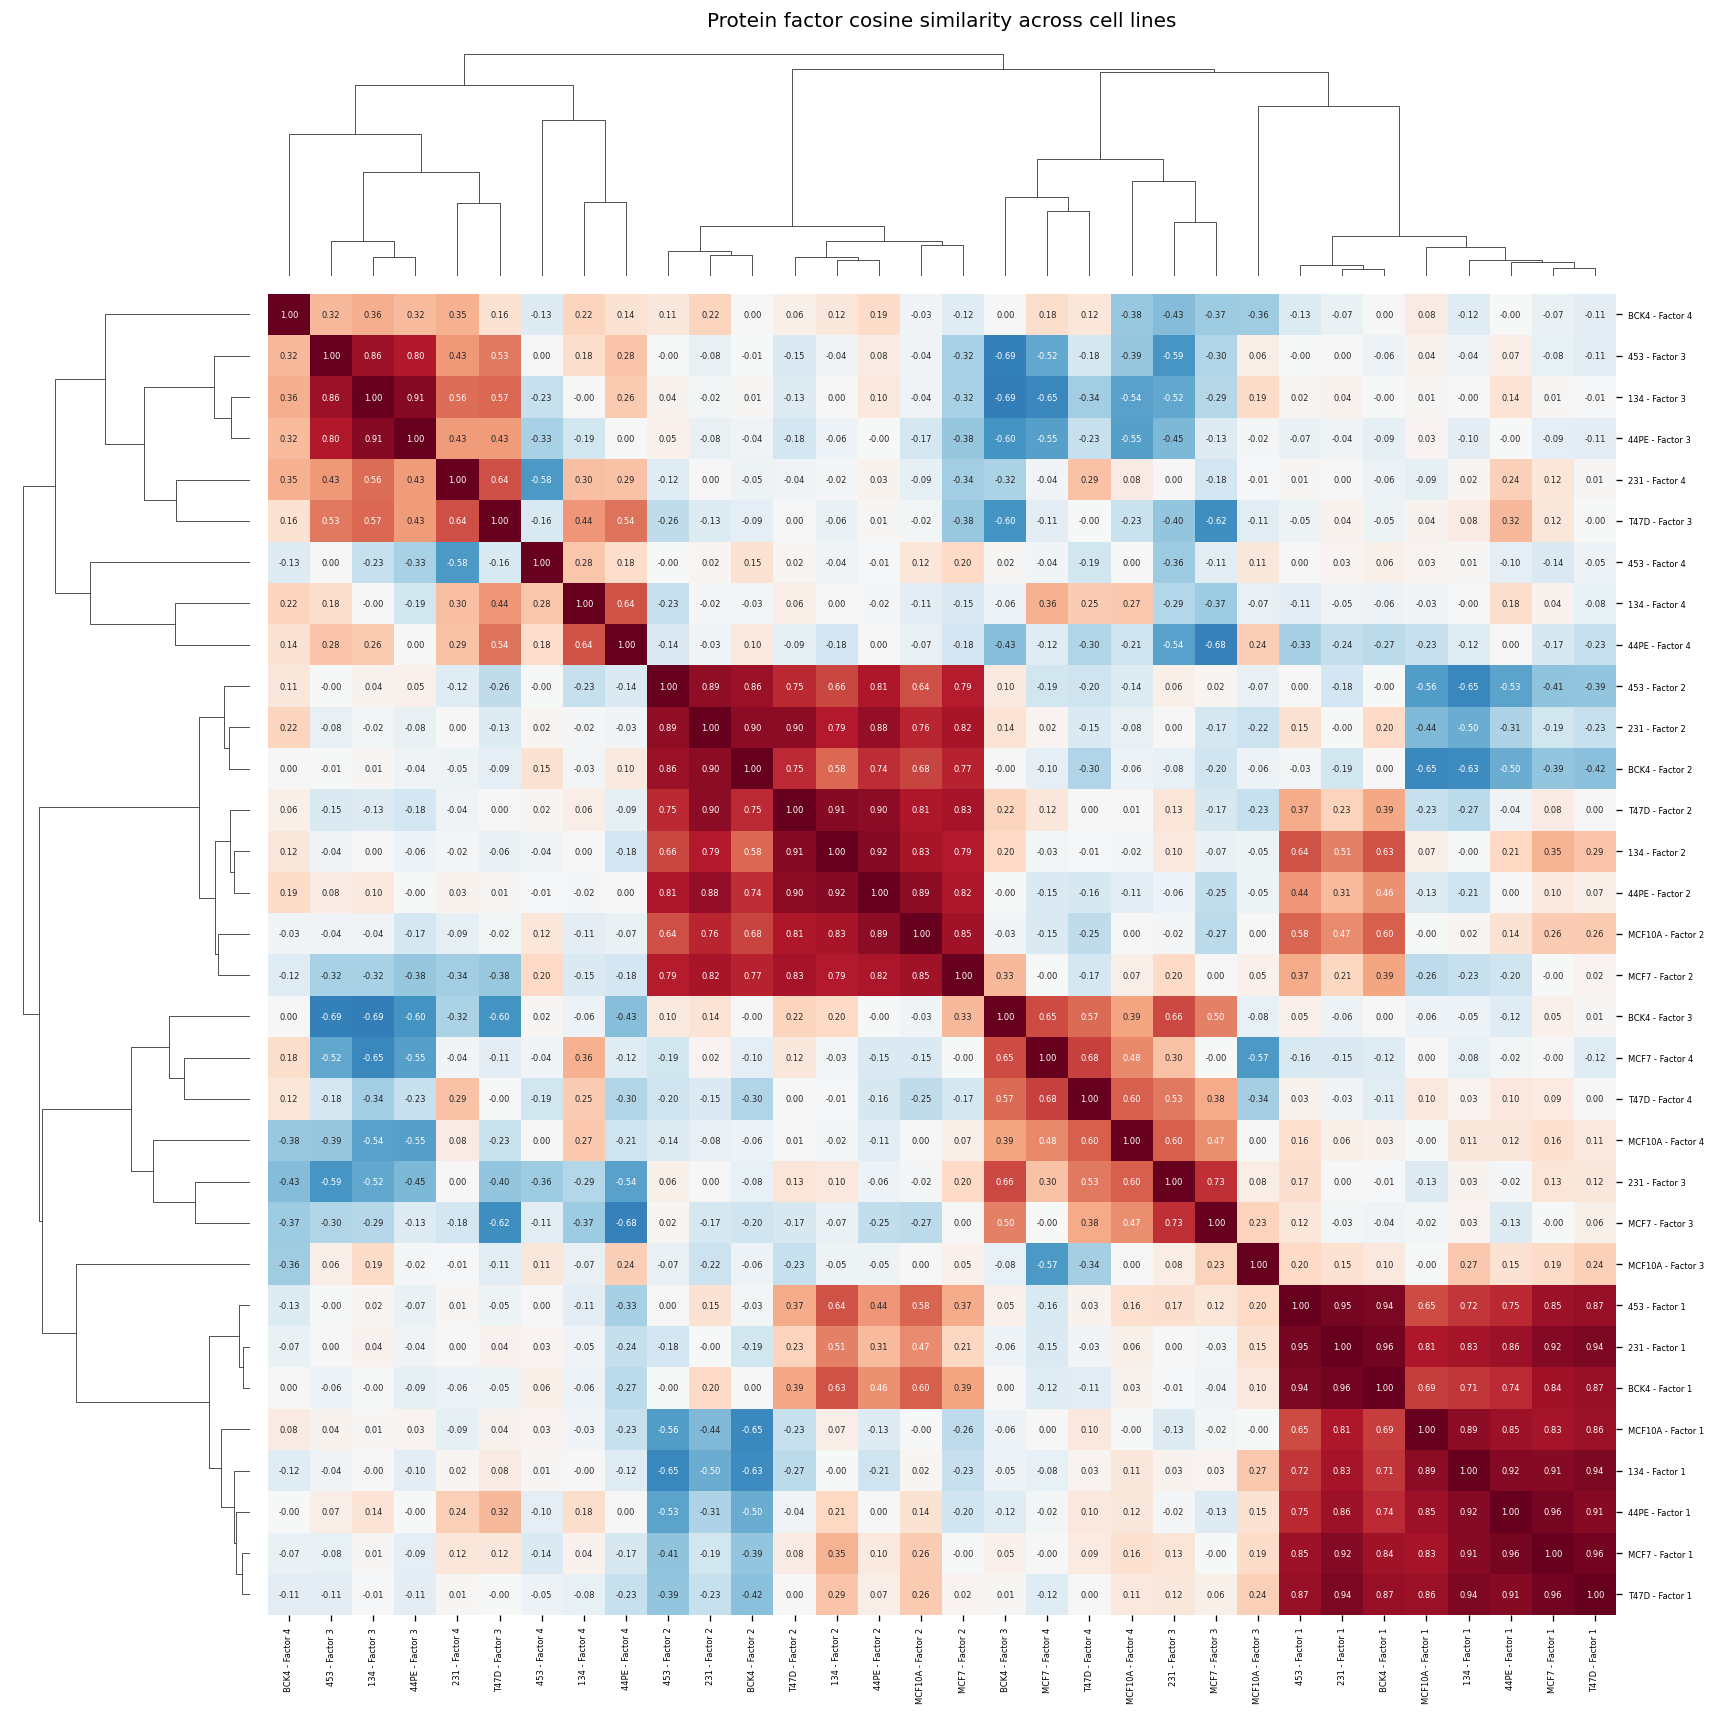

In [6]:
cross_cellline_clustermap(
    protein_factor_df,
    title="Protein factor cosine similarity across cell lines"
);

### 7.2 Treatment factor embeddings:

To compare treatment effects across cell lines, we project each treatment factor into protein space via the phase-averaged core: $\bar{G}_{(1)} P^\top$, where $\bar{G} = \mathcal{G} \times_2 C$ averaged over the phase mode. Each row of the resulting matrix can be viewed as a 22-dimensional protein-space archetype of a treatment factor. PCA, t-SNE, and UMAP embeddings reveal whether treatment factors with similar protein-space signatures recur across cell lines. The clustermap shows pairwise cosine similarity of these signatures.

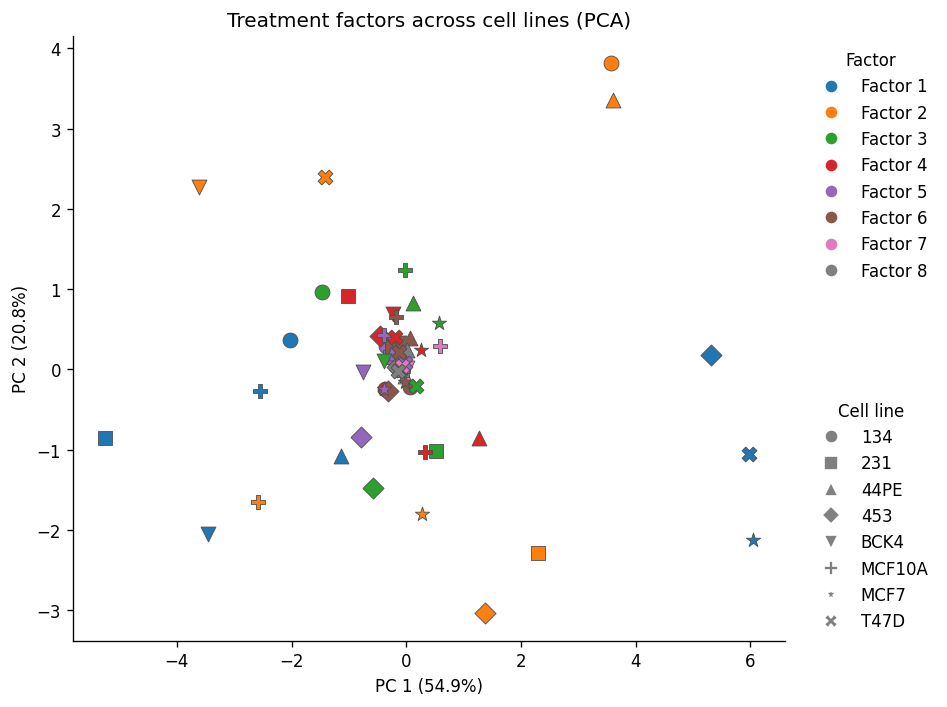

In [7]:
cross_cellline_embedding(
    treatment_factor_df, method="pca",
    title="Treatment factors across cell lines (PCA)"
);

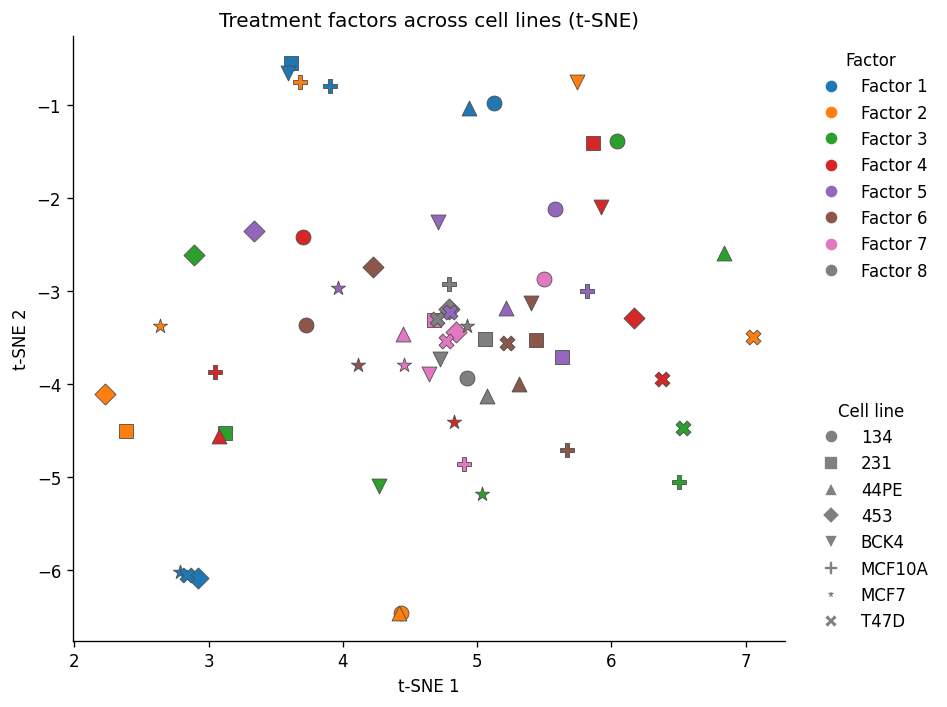

In [8]:
cross_cellline_embedding(
    treatment_factor_df, method="tsne",
    title="Treatment factors across cell lines (t-SNE)"
);

/Users/kaiwycik/.pyenv/versions/3.13.3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


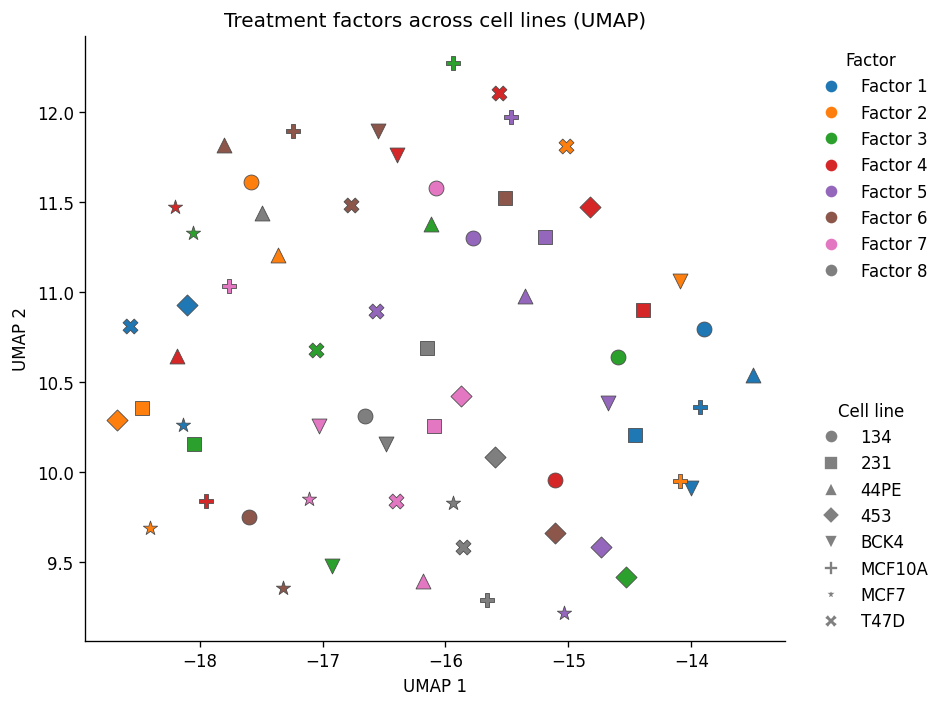

In [9]:
cross_cellline_embedding(
    treatment_factor_df, method="umap",
    title="Treatment factors across cell lines (UMAP)"
);

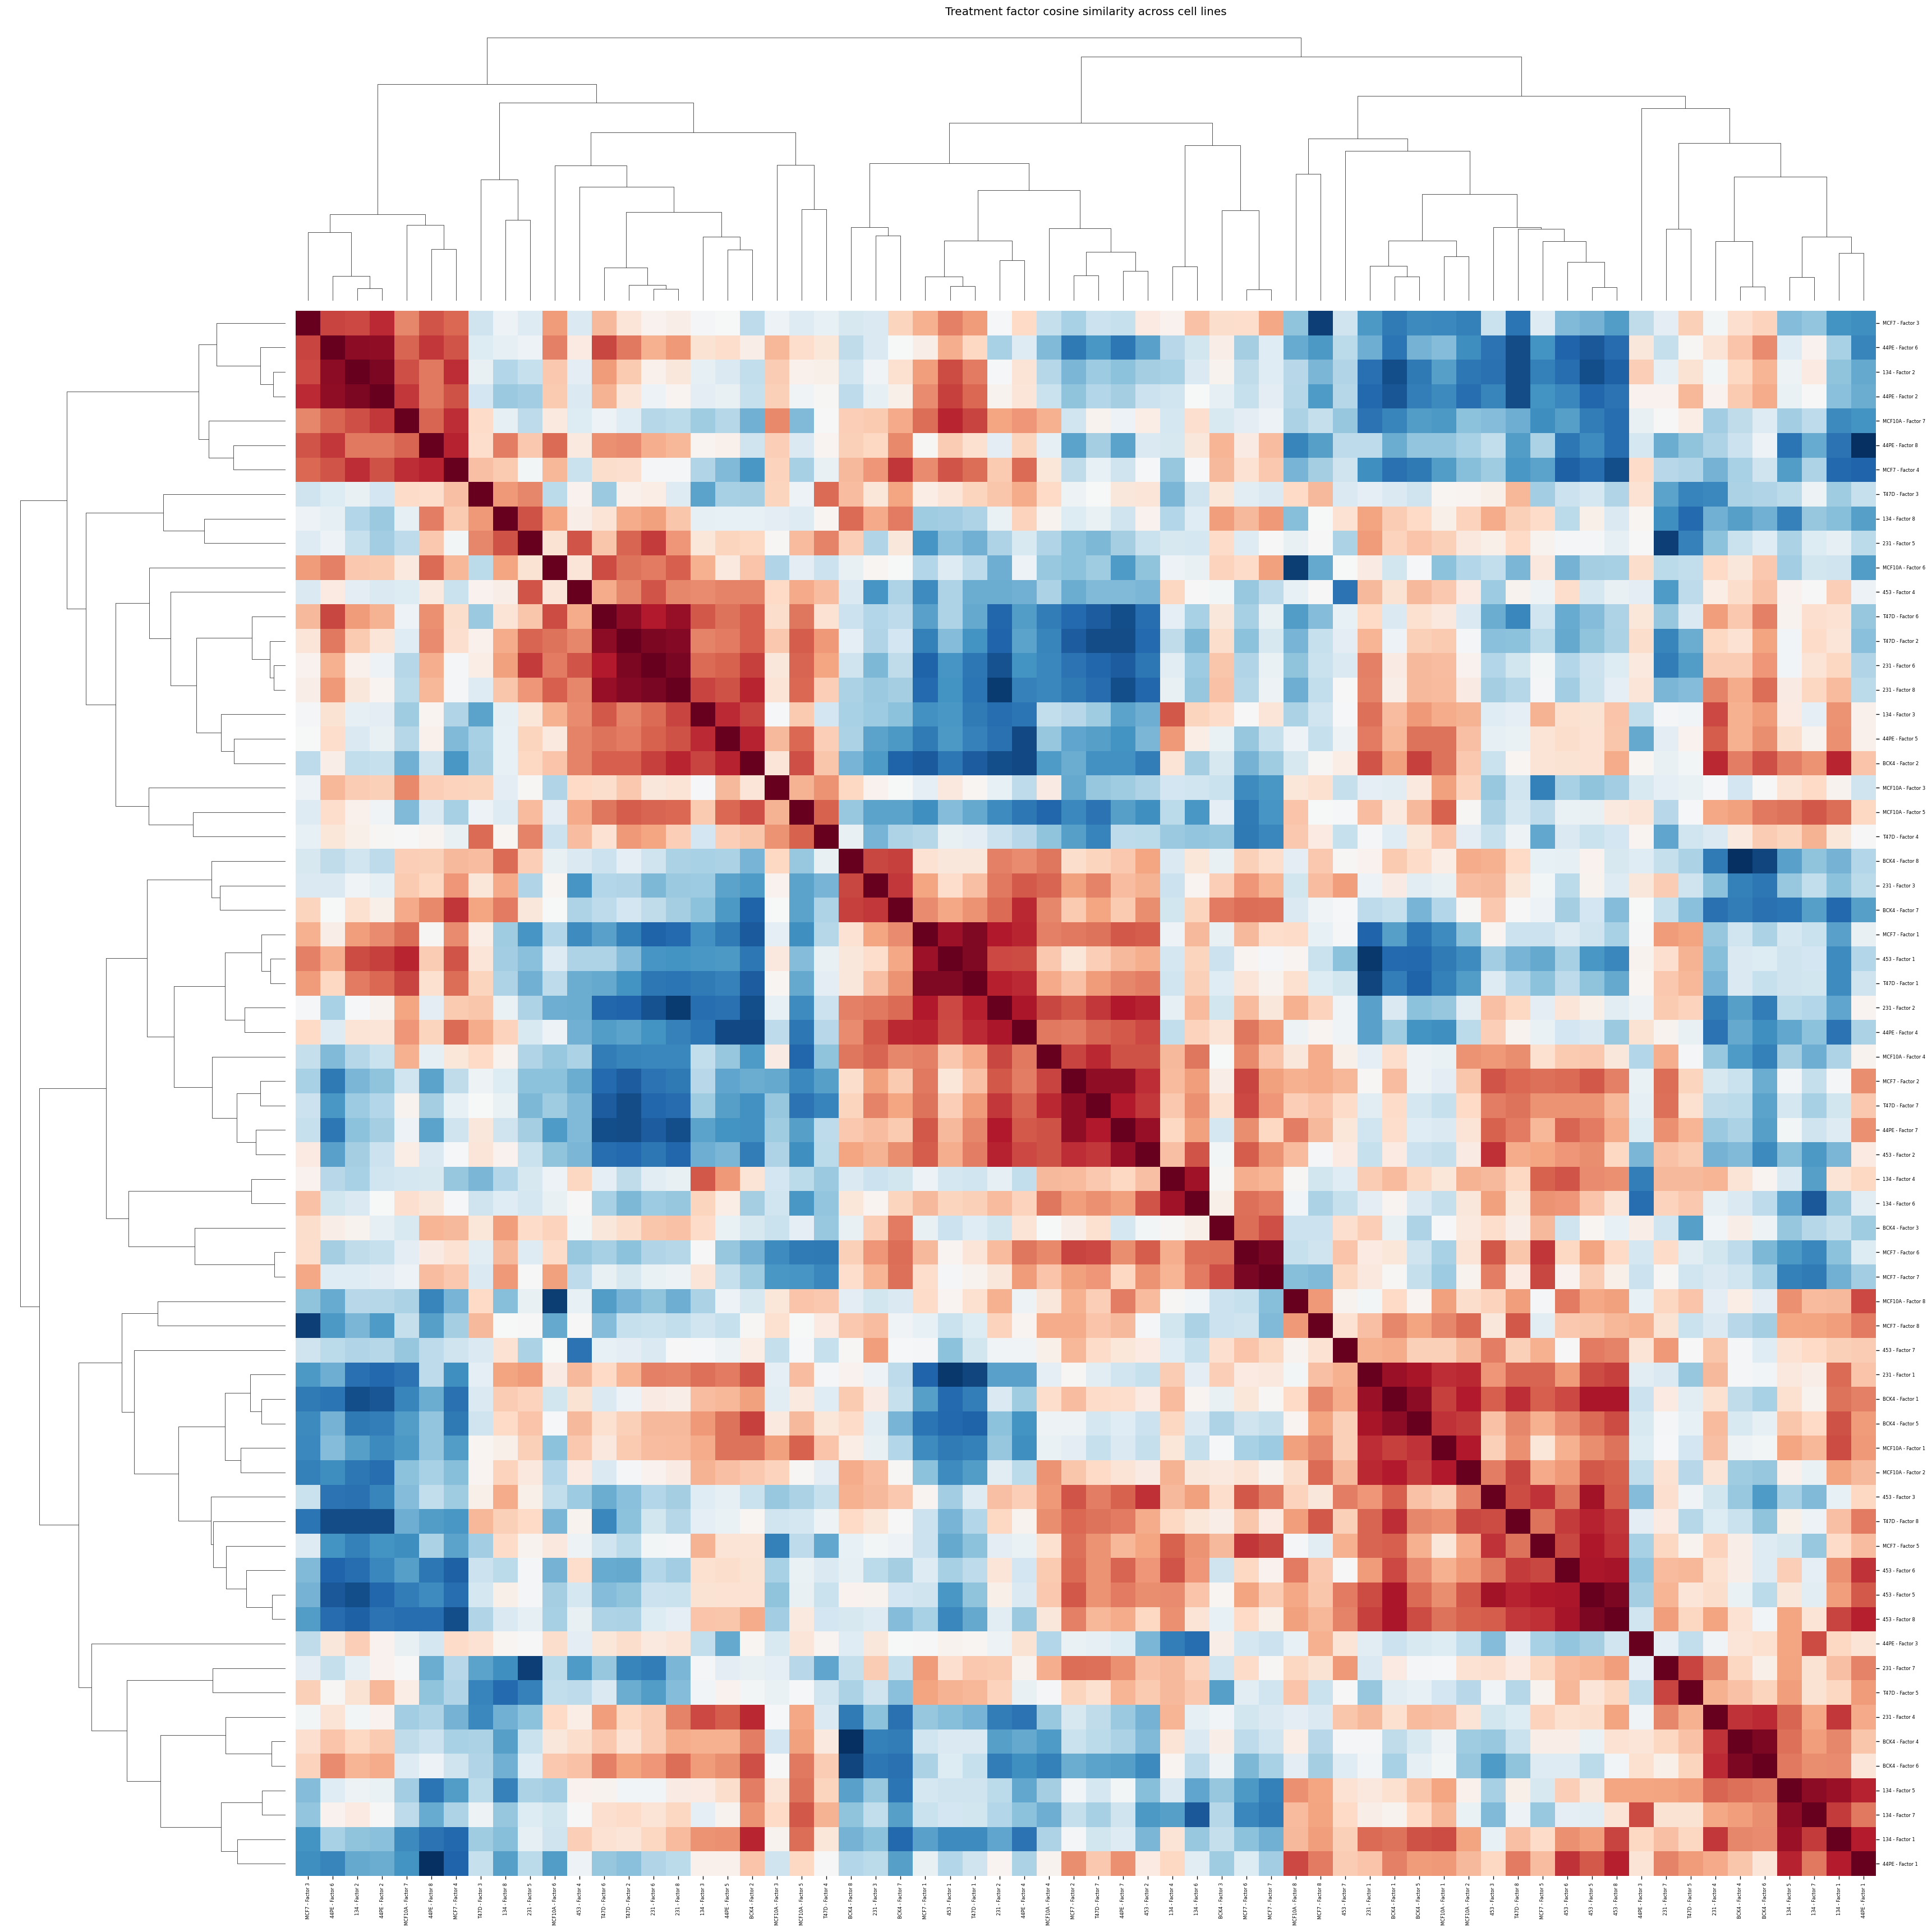

In [10]:
cross_cellline_clustermap(
    treatment_factor_df, annotate=False,
    title="Treatment factor cosine similarity across cell lines"
);

### 7.3 Protein factors grouped by treatment:

For each (cell line, treatment, latent protein-factor) triple, we compute the protein-space vector $\mathcal{F}_{\text{avg}}[t,f] \cdot P_{:,f}$, where $\mathcal{F} = \mathcal{G} \times_1 T \times_2 C$ and $\mathcal{F}_{\text{avg}}$ averages over cell-cycle phase. The scalar $\mathcal{F}_{\text{avg}}[t,f]$ measures how strongly treatment $t$ activates latent protein-factor $f$; multiplying by the loading vector $P_{:,f}$ maps this into protein space.

The resulting matrix has $L \times t \times p_F$ rows (one per cell-line/treatment/factor combination). 

In [11]:
protein_factor_by_treatment_df = cross_cellline_protein_factors_by_treatment(cct_dict)
print(f"Protein factor by treatment matrix: {protein_factor_by_treatment_df.shape}")

protein_factor_by_treatment_df.head(8)

Protein factor by treatment matrix: (256, 22)


Ki67  nuclear_area       p16      CDH1  \
cell_line treatment factor                                                 
134       CVT-313   Factor 1 -0.346580     -0.291634 -0.173555 -0.210618   
                    Factor 2  0.171235      0.128247 -0.419383 -0.069816   
                    Factor 3  0.012938     -0.021690 -0.006352 -0.058778   
                    Factor 4 -0.003005     -0.020810 -0.020219 -0.014526   
          Control   Factor 1 -0.122843     -0.103368 -0.061515 -0.074652   
                    Factor 2  0.004495      0.003367 -0.011010 -0.001833   
                    Factor 3  0.041255     -0.069159 -0.020254 -0.187417   
                    Factor 4 -0.018316     -0.126826 -0.123225 -0.088524   

                                 cycA2     cycE1      CDK2        RB  \
cell_line treatment factor                                             
134       CVT-313   Factor 1 -0.351620 -0.012786 -0.330235 -0.295443   
                    Factor 2  0.111690 -0.560336 -0.134331 -0.254106   
                    Factor 3 -0.015252  0.034691  0.029369  0.029698   
                    Factor 4 -0.004853 -0.013367 -0.000120 -0.019315   
          Control   Factor 1 -0.124629 -0.004532 -0.117049 -0.104718   
                    Factor 2  0.002932 -0.014710 -0.003526 -0.006671   
                    Factor 3 -0.048633  0.110615  0.093644  0.094695   
                    Factor 4 -0.029575 -0.081462 -0.000732 -0.117712   

                                 CycB1       p21  ...      CDK4     cycA1  \
cell_line treatment factor                        ...                       
134       CVT-313   Factor 1 -0.324622 -0.139772  ... -0.053497 -0.188876   
                    Factor 2  0.114176 -0.117608  ... -0.536104 -0.282159   
                    Factor 3 -0.050852 -0.101829  ...  0.020674  0.004384   
                    Factor 4 -0.006814  0.015148  ... -0.034904  0.051977   
          Control   Factor 1 -0.115060 -0.049541  ... -0.018962 -0.066946   
                    Factor 2  0.002997 -0.003087  ... -0.014074 -0.007407   
                    Factor 3 -0.162146 -0.324689  ...  0.065922  0.013978   
                    Factor 4 -0.041528  0.092318  ... -0.212715  0.316769   

                                  PCNA       p53       p27     cycB2  \
cell_line treatment factor                                             
134       CVT-313   Factor 1 -0.273814 -0.170874  0.091360 -0.332805   
                    Factor 2  0.077751 -0.048074 -0.570112  0.105694   
                    Factor 3  0.073689  0.045213 -0.021306 -0.046691   
                    Factor 4  0.013411  0.074917  0.008352 -0.003143   
          Control   Factor 1 -0.097051 -0.060565  0.032382 -0.117961   
                    Factor 2  0.002041 -0.001262 -0.014966  0.002775   
                    Factor 3  0.234964  0.144164 -0.067937 -0.148878   
                    Factor 4  0.081734  0.456569  0.050903 -0.019155   

                                  SKP2      CDT1     cycE2   DNA_int  
cell_line treatment factor                                            
134       CVT-313   Factor 1 -0.338280  0.143568 -0.118463 -0.312960  
                    Factor 2 -0.034208 -0.380694 -0.531243  0.119083  
                    Factor 3  0.034291 -0.060087  0.043768 -0.040020  
                    Factor 4 -0.021865  0.019353 -0.002742  0.022099  
          Control   Factor 1 -0.119901  0.050887 -0.041988 -0.110927  
                    Factor 2 -0.000898 -0.009994 -0.013946  0.003126  
                    Factor 3  0.109339 -0.191593  0.139559 -0.127606  
                    Factor 4 -0.133251  0.117943 -0.016708  0.134677  

[8 rows x 22 columns]

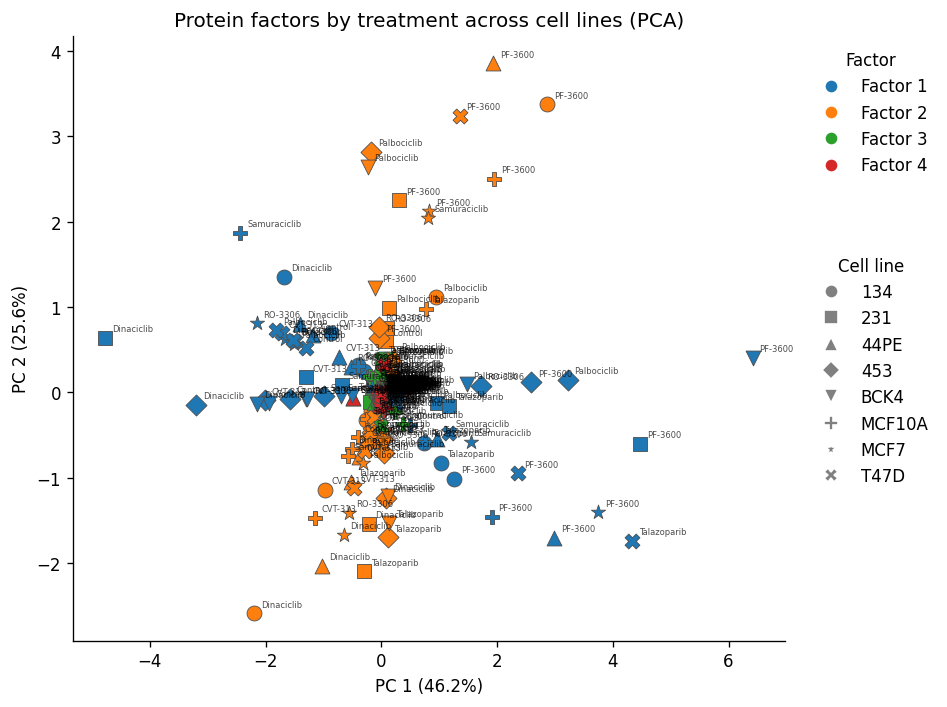

In [12]:
cross_cellline_embedding(
    protein_factor_by_treatment_df, method="pca",
    title="Protein factors by treatment across cell lines (PCA)"
);

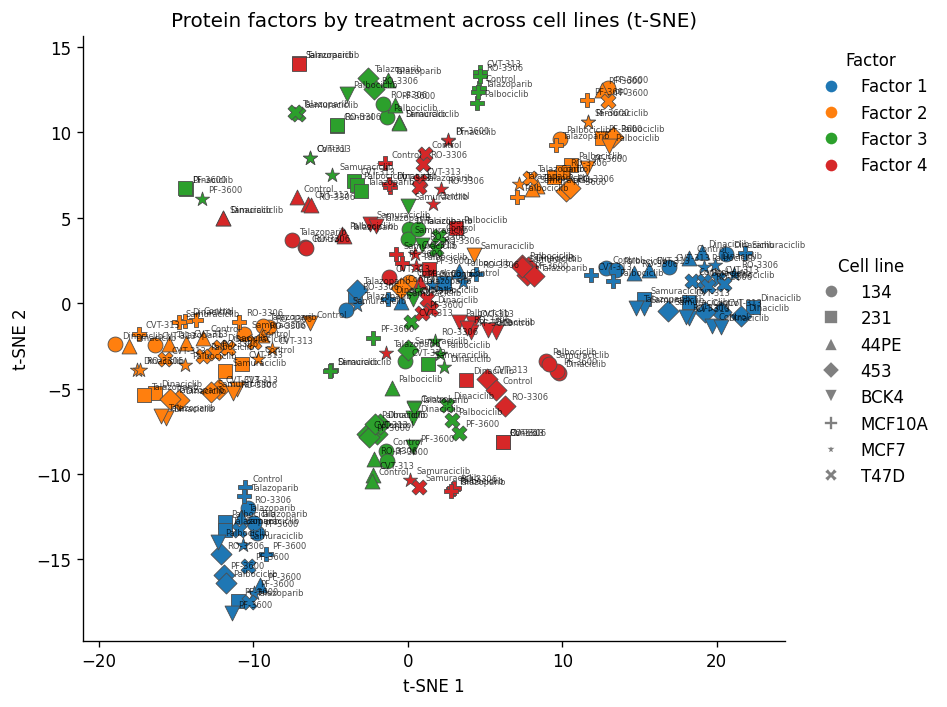

In [13]:
cross_cellline_embedding(
    protein_factor_by_treatment_df, method="tsne",
    title="Protein factors by treatment across cell lines (t-SNE)"
);

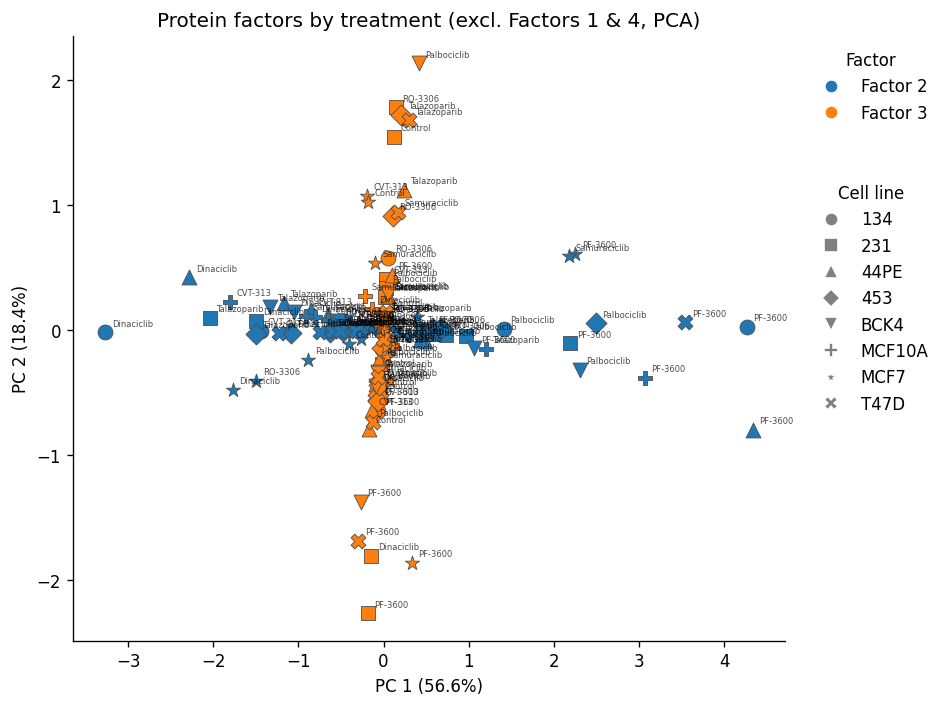

In [14]:
cross_cellline_embedding(
    protein_factor_by_treatment_df, method="pca",
    exclude_factors=["Factor 1", "Factor 4"],
    title="Protein factors by treatment (excl. Factors 1 & 4, PCA)"
);

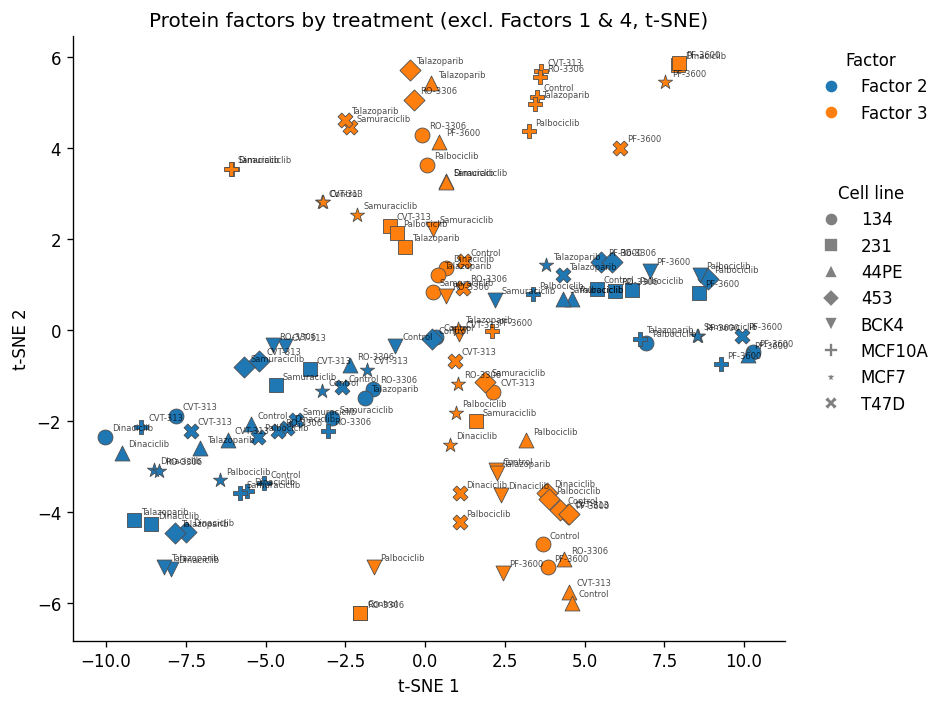

In [15]:
cross_cellline_embedding(
    protein_factor_by_treatment_df, method="tsne",
    exclude_factors=["Factor 1", "Factor 4"],
    title="Protein factors by treatment (excl. Factors 1 & 4, t-SNE)"
);

---